In [1]:
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

import sys
sys.path.append('../src')

from discipline_stats import (plot_distribution, 
                              plot_home_away_distribution, 
                              plot_league_bar, 
                              plot_forest)

In [2]:
with open('../data/processed/team_matches.pkl', 'rb') as f:
    team_matches = pickle.load(f)

serie_a_2425 = team_matches[
    (team_matches['league'] == 'Serie_A') &
    (team_matches['season'] == '2425')
].copy()

print(f"Rows loaded: {len(serie_a_2425)}")
print(f"Matches played: {len(serie_a_2425) // 2}")
print(f"Teams: {serie_a_2425['team'].nunique()}")

Rows loaded: 760
Matches played: 380
Teams: 20


# The Card, the Crowd and the Referee

*When the data stops behaving, the tools have to change*

## Previously on...

In the previous notebook we built a statistical toolkit from scratch using fouls data from Serie A 2024/25. We checked distributions, tested normality, ran Levene's test for equal variance, and compared groups using Student's and Welch's t-tests. We found that away teams foul slightly more than home teams — a small but statistically real effect — and that some teams are genuinely different from the rest of the league, with Verona and Empoli at the high end and Roma and Parma at the low end.

Now we ask the same questions about yellow cards. Same league, same season, same starting questions. But the data is fundamentally different, and that difference is going to force us to expand the toolkit.

## How are yellow cards distributed?

Same starting point as the fouls analysis: before testing anything, we need to understand the shape of the data. A yellow card is a rarer event than a foul — a team commits roughly 12 fouls per match but receives only 2 or 3 yellow cards. Fewer events, integer values only, and a hard floor at zero. Before we even plot anything, those three facts already suggest the distribution will look nothing like the smooth bell curve we worked with before.

Let us see if that instinct is right.


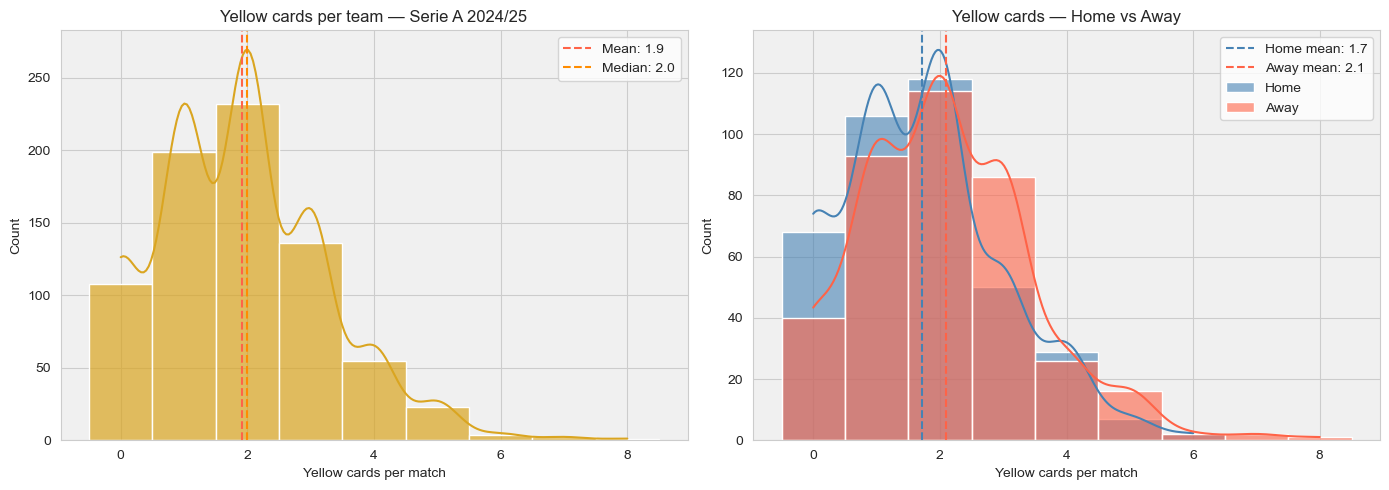

       count  mean   std  min  25%  50%  75%  max
venue                                            
away   380.0  2.10  1.36  0.0  1.0  2.0  3.0  8.0
home   380.0  1.72  1.27  0.0  1.0  2.0  2.0  6.0


In [3]:
home_yc = serie_a_2425[serie_a_2425['venue'] == 'home']['yellow_cards']
away_yc = serie_a_2425[serie_a_2425['venue'] == 'away']['yellow_cards']

with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: overall distribution
    ax = axes[0]
    ax.set_facecolor('#f0f0f0')
    sns.histplot(serie_a_2425['yellow_cards'], bins=range(0, 10),
                 kde=True, color='goldenrod', alpha=0.7, discrete=True, ax=ax)
    ax.axvline(serie_a_2425['yellow_cards'].mean(), color='tomato', linestyle='--',
               linewidth=1.5, label=f"Mean: {serie_a_2425['yellow_cards'].mean():.1f}")
    ax.axvline(serie_a_2425['yellow_cards'].median(), color='darkorange', linestyle='--',
               linewidth=1.5, label=f"Median: {serie_a_2425['yellow_cards'].median():.1f}")
    ax.set_xlabel('Yellow cards per match')
    ax.set_ylabel('Count')
    ax.set_title('Yellow cards per team — Serie A 2024/25')
    ax.legend()

    # Right: home vs away
    ax = axes[1]
    ax.set_facecolor('#f0f0f0')
    sns.histplot(home_yc, bins=range(0, 10), kde=True, discrete=True,
                 color='steelblue', alpha=0.6, label='Home', ax=ax)
    sns.histplot(away_yc, bins=range(0, 10), kde=True, discrete=True,
                 color='tomato', alpha=0.6, label='Away', ax=ax)
    ax.axvline(home_yc.mean(), color='steelblue', linestyle='--', linewidth=1.5,
               label=f'Home mean: {home_yc.mean():.1f}')
    ax.axvline(away_yc.mean(), color='tomato', linestyle='--', linewidth=1.5,
               label=f'Away mean: {away_yc.mean():.1f}')
    ax.set_xlabel('Yellow cards per match')
    ax.set_ylabel('Count')
    ax.set_title('Yellow cards — Home vs Away')
    ax.legend()

    plt.tight_layout()
    plt.show()

print(serie_a_2425.groupby('venue')['yellow_cards'].describe().round(2))


The contrast with the fouls distribution is immediate. Gone is the smooth bell curve centred around a single peak. What we have instead is a jagged, right-skewed shape with a hard floor at zero and values crowded into the 0 to 4 range.

A few things stand out from the numbers:

**Mean (1.9) and median (2.0) are close**, as they were for fouls, but the visual story is very different. The distribution has a strong peak at 2, a substantial bar at 0, and a long right tail that thins out slowly. This is not a bell curve with a few rough edges. It is a fundamentally different shape.

**The standard deviation (roughly 1.3) is large relative to the mean.** For fouls, the standard deviation was about 30% of the mean. Here it is nearly 70%. Yellow cards are proportionally much noisier data.

**Zero is not rare.** Home teams finished with zero yellow cards in a meaningful number of matches, as the left plot makes clear. With fouls, a zero was essentially impossible. Here it is a normal part of the distribution.

On the right, the home vs away split already hints at something: away teams average 2.1 cards against 1.7 for home teams, a gap of 0.4 cards per match. Proportionally this is larger than the fouls gap we found. Whether it is real or noise is the question we will get to. But first, we need to be honest about what this shape means for the tools we plan to use.

Notice also how the KDE curves look awkward, especially on the right plot. They are trying to fit a smooth continuous line through data that only takes integer values. The wiggles and dips between integers are artefacts of the smoothing, not real features of the data. This is our first warning sign: tools designed for continuous data are already struggling just to describe what they see.

### The Shape of the Cards

A distribution of rare, independent events counted over a fixed interval follows a **Poisson distribution**, named after the French mathematician Siméon Denis Poisson who described it in 1837. Yellow cards per match fit the description well: each card is a relatively rare event, matches are our fixed interval, and the Poisson distribution is discrete by nature, right-skewed for small means, and has a hard floor at zero — exactly what we see here.

This matters because the normal distribution is sometimes used as an approximation for Poisson data, but only when the mean is large enough, roughly above 10, for the distribution to become approximately symmetric. With a mean of 1.9, we are far from that regime. The Gaussian approximation that served us reasonably well for fouls is not appropriate here.

### When the model lies, and tells the truth anyway

*A brief digression, for those who find this kind of thing as interesting as I do. Then you should be worried about yourself.*

The Poisson distribution assumes that events are independent: one yellow card should not influence the probability of the next. But yellow cards are clearly not independent. A team that just received a booking might tighten up tactically, or lose its composure entirely. A referee who has already shown three cards in twenty minutes is operating in a different emotional environment than one who has shown none. The scoreline, the crowd, the fatigue in the legs of a holding midfielder who has been chasing shadows for seventy minutes — all of these create invisible threads connecting one event to the next.

And yet. The distribution looks Poisson.

This is, I think, one of the genuinely surprising things about football data, and one of the reasons I keep coming back to it. The match itself is irreducibly complex: twenty-two players, a referee, a crowd of thousands, a ball that bounces in ways that defy prediction. Every minute contains a hundred micro-decisions, collisions, adjustments, moments of brilliance and stupidity. You genuinely do not know what will happen next. That is why you watch.

But zoom out to the season level, aggregate all that chaos across hundreds of matches, and something strange happens: the complexity washes out. The countless dependencies, the emotional cascades, the tactical adjustments interact in so many ways, with so many small and opposing effects, that the aggregate behaviour converges to something that looks almost boringly random. A simple Poisson process. Independent events. As if none of that complexity had happened at all.

This phenomenon has a name in probability theory: the ***emergence of randomness from complexity***. It appears in queuing systems, earthquake frequencies, the number of goals scored in a match, and apparently in yellow cards too. When a system has enough interacting components, each contributing a small unpredictable effect, the macro-level outcome can look indistinguishable from a process with no structure at all.

I find this genuinely beautiful. The unpredictability that makes football worth watching: the thing that keeps us in our seat at 2-0 down with ten minutes to go is the same thing that makes the data look random when you step back far enough. The passion and the statistics are not in tension. They are describing the same thing from different distances.

But the practical implication of all this is uncomfortable. Yellow cards behave like a Poisson process, and the normal distribution is a poor approximation for Poisson data with a small mean. The toolkit we built in the fouls notebook was designed for bell-shaped, continuous data. We are about to find out how it handles something that is neither.

## Normality check: the moment of truth

We ran the same normality checks in the fouls notebook and the data passed, with reservations. The $W$ statistics were close to 1, the Q-Q plots followed the diagonal, and we concluded the Gaussian approximation was good enough for our purposes. We already suspect that will not be the case here. Let us see how bad it is.

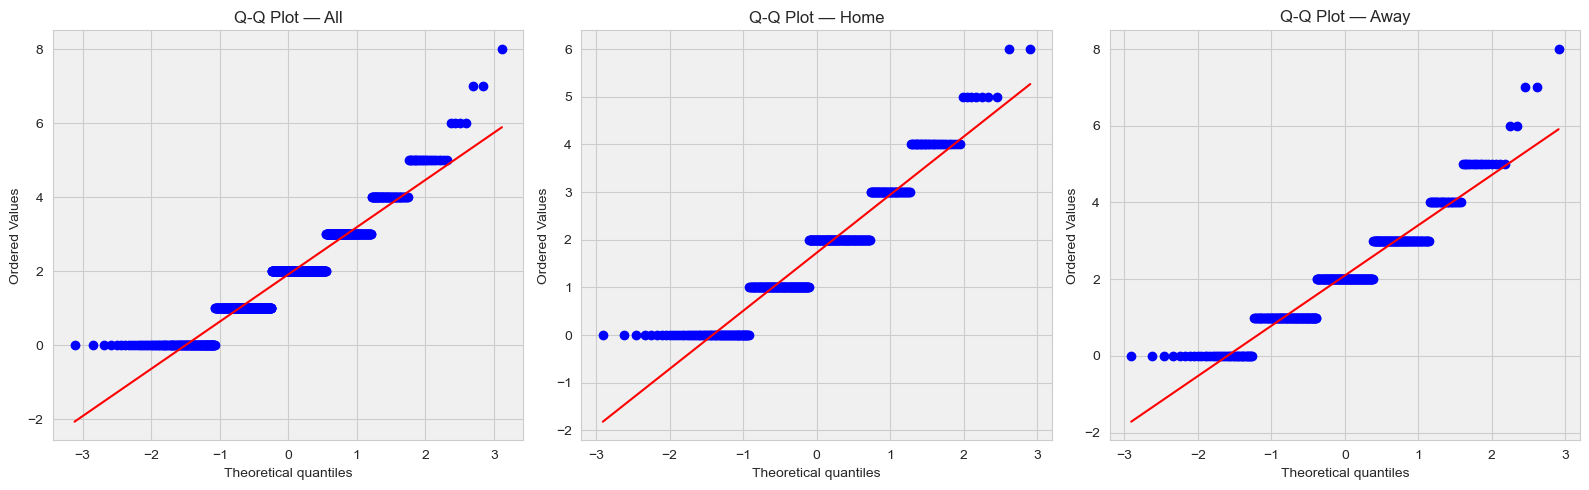

In [4]:
with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for ax, (label, data) in zip(axes, [
        ('All', serie_a_2425['yellow_cards']),
        ('Home', home_yc),
        ('Away', away_yc)
    ]):
        ax.set_facecolor('#f0f0f0')
        stats.probplot(data, dist="norm", plot=ax)
        ax.set_title(f'Q-Q Plot — {label}')

    plt.tight_layout()
    plt.show()


In [5]:
for label, data in [
    ('All',  serie_a_2425['yellow_cards']),
    ('Home', home_yc),
    ('Away', away_yc)
]:
    w, p = stats.shapiro(data)
    normal = 'Normal (p>0.05)' if p > 0.05 else 'Not normal (p<0.05)'
    print(f"{label:6s} -- W={w:.4f}, p={p:.6f}  {normal}")


All    -- W=0.9182, p=0.000000  Not normal (p<0.05)
Home   -- W=0.9113, p=0.000000  Not normal (p<0.05)
Away   -- W=0.9196, p=0.000000  Not normal (p<0.05)


This is not the same conversation we had in the fouls notebook.

With fouls, the $W$ statistics were 0.988 and 0.992: close enough to 1 that we could reasonably argue the data was approximately normal. The Q-Q plots showed only mild deviations at the tails and so we ran the t-test with some confidence.

Here, the $W$ statistics sit at 0.911 to 0.920, and the p-values are not "small but debatable". They are zero to six decimal places! The test is not raising a flag. It is screaming for help.

The Q-Q plots make the problem visible. Instead of points following the diagonal with minor wobbles, we see a staircase: flat horizontal bands at 0, 1, 2, 3, 4, with gaps between them. This is what discrete data looks like when you force it through a tool built for continuous values. The normal distribution expects an infinite continuum of possible values. Yellow cards can only be integers. The two are fundamentally incompatible.

This is not a case of "technically not normal but close enough." The data lives in a different world from the bell curve. The t-test, which we used with reasonable confidence for fouls, is on genuinely shaky ground here.

So what do we do? We could run the t-test anyway and hope the Central Limit Theorem provides enough protection with 380 observations per group. But we can do better. There are tests that make no assumptions about the shape of the data at all. This is the moment to introduce them.

## When the tools need upgrading

### A brief and entirely justified historical detour

Before we introduce the new tools, I [want to tell you about a (not "girl" but) story](https://www.youtube.com/watch?v=UyDqULz9ECc&list=RDUyDqULz9ECc&start_radio=1) where they come from. As with the t-test and Gosset's beer, the origin story is more grounded than you might expect.

[Frank Wilcoxon](https://en.wikipedia.org/wiki/Frank_Wilcoxon) was a physical chemist employed by American Cyanamid, a chemical company, whose job involved comparing the effectiveness of different pesticide preparations. He had data, he had questions, and he had a problem: the standard statistical tests of the time required lengthy hand calculations. There were no computers. Every t-statistic had to be computed by hand, step by step, for every comparison. Wilcoxon was a chemist, not a mathematician, and he needed to get his work done.

His insight was elegant and clever in its simplicity. Instead of working with the raw values, replace them with their ranks. If you have two groups and you want to know whether one tends to produce larger values than the other, you do not need the actual numbers. You just need to know their order. Ranks are much faster to work with than raw values, and they carry enough information to answer the question. He published his method in 1945, using data from fly spray experiments with just eight observations per group. Unglamorous problem, beautiful solution.

Two years later, in 1947, [Henry Mann](https://en.wikipedia.org/wiki/Henry_Mann) and his doctoral student [Donald Whitney](https://en.wikipedia.org/wiki/D._Ransom_Whitney) at Ohio State University took Wilcoxon's practical shortcut and gave it mathematical rigour. Mann was no ordinary collaborator: an Austrian-born mathematician who had fled Vienna in 1938, he had already won the Cole Prize in number theory, one of the most prestigious awards in mathematics, the year before. A real mathematician, whose PhD supervisor was second cousin of the famous director [Wilhelm Furtwängler](https://en.wikipedia.org/wiki/Wilhelm_Furtw%C3%A4ngler). Why I am telling you all these  facts? Just in case you are preparing to participate to "Who Wants to be a Millionaire?". Anyway, Mann, together with Whitney, proved the formal properties of Wilcoxon's statistic, extended it to unequal sample sizes, derived its distribution, and published the probability tables that made it usable beyond Wilcoxon's immediate problem.

The test carries all three names for a reason. Wilcoxon had the practical insight. Mann and Whitney built the theory. A chemist killing flies and too lazy to learn all the arithmetic needed to solve his problem, a refugee mathematician and his student too lazy to have a true job in the industry turning the shortcut into a theorem. The usual pattern: necessity first, rigour second. And laziness as true drive.

And crucially: neither Wilcoxon nor Mann and Whitney assumed anything about the shape of the data. That was the whole point. The test was designed for the messy, non-normal, real-world data that parametric methods struggled with. Which is exactly what we have in front of us.

### How does it actually work?

The idea behind the Mann-Whitney test is simple enough to demonstrate by hand. Forget yellow cards for a moment. Take two small groups of matches and ask a single question: do the values in one group tend to be larger than the values in the other?

Suppose you have two teams [*High* and *Low*](https://en.wikipedia.org/wiki/High_and_Low_(1963_film)): you regard the team *High* to be very aggressive and commit a lot of fouls during games (picture someone like El Cholo Simeone, the man seen by many fans to have turned tactical fouling into an art form, as their manager), while believing that *Low* is calm and possession based (Pep Guardiola as their manager might be a good pick for *Low*)  

Here are six matches, three from a high-fouling team and three from a low-fouling team:

| Match | Team | Fouls |
|-------|------|-------|
| A | High | 18 |
| B | High | 14 |
| C | High | 11 |
| D | Low | 9 |
| E | Low | 13 |
| F | Low | 7 |

Step 1: ignore the group labels and rank all six values together, from lowest to highest.

| Match | Team | Fouls | Rank |
|-------|------|-------|------|
| F | Low | 7 | 1 |
| D | Low | 9 | 2 |
| C | High | 11 | 3 |
| E | Low | 13 | 4 |
| B | High | 14 | 5 |
| A | High | 18 | 6 |

Step 2: sum the ranks for each group.

- High-fouling team: ranks 3 + 5 + 6 = **14**
- Low-fouling team: ranks 1 + 2 + 4 = **7**

Step 3: ask whether this split would be surprising if the two groups were identical. If there were no real difference, the ranks would mix randomly between the groups. With three observations in each group, the ranks 1 through 6 could be distributed in many ways. The Mann-Whitney U statistic formalises this question: how often would random shuffling produce a rank sum at least as extreme as the one we observed?

That is the entire test. No assumption about normality. No assumption about equal variance. Just ranks, sums, and a question about how surprising the result is.

In [6]:
import pandas as pd
import numpy as np

# Two small teams, three matches each
example = pd.DataFrame({
    'team': ['High', 'High', 'High', 'Low', 'Low', 'Low'],
    'fouls': [18, 14, 11, 9, 13, 7]
})

# Step 1: rank all values together
example['rank'] = example['fouls'].rank()
print("Step 1: rank all values together")
print(example.sort_values('rank').to_string(index=False))
print()

# Step 2: sum ranks by group
rank_sums = example.groupby('team')['rank'].sum()
print("Step 2: rank sums by group")
print(rank_sums.to_string())
print()

# Step 3: compute U statistic
n1 = n2 = 3
U_high = rank_sums['High'] - n1 * (n1 + 1) / 2
U_low  = rank_sums['Low']  - n2 * (n2 + 1) / 2
print(f"Step 3: U statistic")
print(f"  U (High): {U_high:.0f}")
print(f"  U (Low):  {U_low:.0f}")
print(f"  U_high + U_low = {U_high + U_low:.0f}  (should equal n1 * n2 = {n1*n2})")
print()

# Step 4: verify with scipy
from scipy import stats
high_fouls = example[example['team'] == 'High']['fouls']
low_fouls  = example[example['team'] == 'Low']['fouls']
u_stat, p_val = stats.mannwhitneyu(high_fouls, low_fouls, alternative='two-sided')
print(f"Step 4: scipy verification")
print(f"  U={u_stat:.0f}, p={p_val:.4f}")


Step 1: rank all values together
team  fouls  rank
 Low      7   1.0
 Low      9   2.0
High     11   3.0
 Low     13   4.0
High     14   5.0
High     18   6.0

Step 2: rank sums by group
team
High    14.0
Low      7.0

Step 3: U statistic
  U (High): 8
  U (Low):  1
  U_high + U_low = 9  (should equal n1 * n2 = 9)

Step 4: scipy verification
  U=8, p=0.2000


The numbers tell a clean story.

After ranking all six values together, the High team holds ranks 3, 5 and 6 — the upper half of the table. The Low team holds ranks 1, 2 and 4 — the lower half, with one exception. The rank sums reflect this: 14 for High, 7 for Low.

The U statistic formalises the question. U for High is 8, which means that in 8 out of the 9 possible head-to-head comparisons between a High match and a Low match, the High value was larger. U for Low is 1, meaning the Low team won only one of those nine comparisons. Notice that U_high + U_low = 9, which always equals n1 times n2. This is a useful sanity check.

The p-value is 0.20. With only three observations per group, even a fairly clean separation like this one does not reach significance. There are simply not enough data points to rule out that this ranking happened by chance. This is the small-sample problem in action: the direction looks right, but we cannot be confident.

Scipy returns U=8, confirming our hand calculation exactly. From here on, we let scipy handle the arithmetic. The logic underneath is always the same: rank everything together, count how often one group beats the other, ask whether that count would be surprising under the null hypothesis.

Now let us apply it to the full dataset, where 380 observations per group give the test something real to work with.

### Permutation test: the same question, asked differently

If the rank-based logic of Mann-Whitney feels like too much mathematical machinery (No, it is not! It is elegant and smart!) there is a completely different way to ask the same question. One that requires no formula, no ranking, and no statistical tables. Just a lot of shuffling.

The permutation test starts from an even simpler question: if there were no real difference between the two groups, would it matter which label we assigned to each observation?

If home and away teams receive yellow cards at the same rate, then the labels "home" and "away" are essentially arbitrary. We could shuffle them randomly and the difference in group means would not change much. But if the labels carry real information, if away teams genuinely receive more cards, then shuffling them destroys that signal, and the observed difference becomes hard to reproduce by chance.

The test works exactly like that. We compute the observed difference between the two groups. Then we shuffle the labels thousands of times, computing the difference each time. The p-value is simply the proportion of shuffles that produced a difference at least as large as the one we actually observed. No assumptions about normality, no assumptions about variance. Just repeated shuffling and counting. Brute force, in the best possible sense.

The permutation test and Mann-Whitney are complementary. Mann-Whitney asks whether one group tends to produce larger values than the other, based on ranks. The permutation test asks whether the observed difference in means could have happened by chance, based on repeated shuffling. When both agree, the conclusion is solid. When they disagree, it is worth understanding why.

## Home vs Away: do away teams get more yellow cards?

Same question as the fouls notebook, same structure. We know the data is not normal, so we run the full battery: Levene for equal variance, Student and Welch for comparison with what we used before, Mann-Whitney and permutation as the tools we trust here. We want to see whether they agree, and if they disagree, we want to understand why.


In [7]:
from discipline_stats import test_home_away

# Tests we already know: Levene, Student, Welch
results_ha = test_home_away(serie_a_2425, 'yellow_cards')
results_ha.show('levene', 'student_t', 'welch_t')

# Mann-Whitney: does one group tend to produce larger values than the other?
u_stat, u_p = stats.mannwhitneyu(home_yc, away_yc, alternative='two-sided')
n1, n2 = len(home_yc), len(away_yc)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
print(f"\nMann-Whitney U:   U={u_stat:.1f}, p={u_p:.4f}")
print(f"Rank-biserial:    {rank_biserial:.4f}")

# Permutation test: would random shuffling produce a difference this large?
np.random.seed(42)
observed_diff = away_yc.mean() - home_yc.mean()
pooled = np.concatenate([home_yc.values, away_yc.values])
n_home = len(home_yc)
perm_diffs = np.array([
    (lambda p: p[n_home:].mean() - p[:n_home].mean())(np.random.permutation(pooled))
    for _ in range(10_000)
])
p_perm = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f"\nPermutation test: p={p_perm:.4f}")
print(f"Observed diff:    {observed_diff:.4f}")


Home vs Away -- yellow_cards
--------------------------------------------------
  home_mean                 1.7237
  away_mean                 2.0974
  difference (away-home)    +0.3737
  home_std                  1.2686
  away_std                  1.3604
  home_n                    380
  away_n                    380
--------------------------------------------------
  levene                    stat=0.0275, p=0.8683  (Not sig.)
  student_t                 stat=-3.9161, p=0.0001  (Sig.)
  welch_t                   stat=-3.9161, p=0.0001  (Sig.)
--------------------------------------------------
  cohens_d                  0.2841
  rank_biserial             0.1578

Mann-Whitney U:   U=60804.0, p=0.0001
Rank-biserial:    0.1578

Permutation test: p=0.0000
Observed diff:    0.3737


The rank-biserial correlation measures the same thing as Cohen's $d$ does for the t-test: not whether the difference is significant, but how large it is. Specifically, it tells us the probability that a randomly picked away match produced more yellow cards than a randomly picked home match, expressed as a value between -1 and +1. A rank-biserial of 0.16 means that in about 58% of all possible home-away pairs, the away team received more cards. Small, but consistently pointing in the same direction.

All four tests agree, and the signal is much stronger than what we found for fouls.

With fouls, the home/away difference produced p=0.036 and Cohen's d of 0.15 (significant but barely, sitting just below the threshold). Here, every test returns p=0.0001 and Cohen's d is 0.28, nearly double. The away effect for yellow cards is not only real, it is more pronounced than the away effect for fouls.

A few things worth reading carefully:

**Levene's test confirms equal variance** (p=0.87). The spread of yellow cards is similar for home and away teams, which is why Student's and Welch's return identical results. No correction needed.

**All four tests agree.** This is the best possible outcome when working with non-normal data. The t-tests, which we know are on shaky ground here, reach the same conclusion as Mann-Whitney and the permutation test, which make no assumptions about shape. When parametric and non-parametric tests agree, the result is robust regardless of which tool you trust more.

**Cohen's d of 0.28** sits between small and medium. The rank-biserial of 0.16 tells the same story in different units: if you picked a random home match and a random away match, the away team received more yellow cards about 58% of the time. Modest, but consistent.

**Why is the yellow card effect stronger than the fouls effect?** This is the interesting question. Away teams foul slightly more, but the gap is small and the effect is weak. Away teams receive meaningfully more yellow cards, and the signal is much cleaner. If fouling were the only driver of bookings, we would expect the two effects to be similar in size. The fact that they are not suggests something else is at work: referee judgement, crowd pressure, or both. The same foul committed by an away player may be more likely to produce a card than the same foul committed by a home player. We cannot prove that from this data alone, but the numbers are consistent with it. It is also worth keeping in mind that we are looking at one league and one season. This result might be specific to Serie A 2024/25: an unusually card-heavy season, a particular cohort of referees, a specific set of teams or different indications from the referee board. Testing whether the home/away yellow card effect holds across all five leagues and across fourteen seasons is exactly the kind of question the later articles in this series are built to answer.


## A cross-league comparison: Serie A vs Premier League

In the fouls notebook, the comparison between Serie A and the Premier League produced one of the strongest effects we found: nearly three fouls per match difference, Cohen's d of 0.53. The stereotype of Italian football as more foul-prone survived contact with a t-test.

Yellow cards tell a different story, or possibly the same story told differently. Let us find out.

In [8]:
from discipline_stats import compare_two_groups

serie_a = team_matches[
    (team_matches['league'] == 'Serie_A') &
    (team_matches['season'] == '2425')
]['yellow_cards']

premier = team_matches[
    (team_matches['league'] == 'Premier_League') &
    (team_matches['season'] == '2425')
]['yellow_cards']

results_leagues = compare_two_groups(serie_a, premier,
                                     label_a='Serie A',
                                     label_b='Premier League')


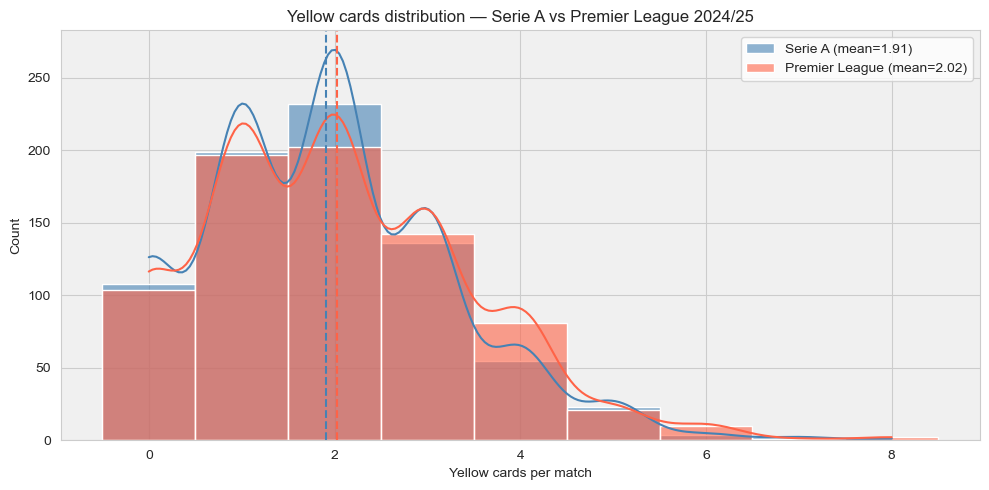

Serie A vs Premier League
--------------------------------------------------
  mean_Serie A              1.9105
  mean_Premier League       2.0250
  std_Serie A               1.3277
  std_Premier League        1.4172
  n_Serie A                 760
  n_Premier League          760
  mean_diff                 -0.1145
--------------------------------------------------
  student_t                 stat=-1.6250, p=0.1044  (Not sig.)
  welch_t                   stat=-1.6250, p=0.1044  (Not sig.)
  mann_whitney              stat=277165.5000, p=0.1629  (Not sig.)
  permutation               p=0.1055  (Not sig.)
--------------------------------------------------
  cohens_d                  -0.0834
  rank_biserial             0.0403


In [9]:
pl_2425 = team_matches[
    (team_matches['league'] == 'Premier_League') &
    (team_matches['season'] == '2425')
]['yellow_cards']

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_facecolor('#f0f0f0')

    sns.histplot(serie_a, bins=range(0, 10), kde=True, discrete=True,
                 color='steelblue', alpha=0.6, label=f'Serie A (mean={serie_a.mean():.2f})', ax=ax)
    sns.histplot(pl_2425, bins=range(0, 10), kde=True, discrete=True,
                 color='tomato', alpha=0.6, label=f'Premier League (mean={pl_2425.mean():.2f})', ax=ax)

    ax.axvline(serie_a.mean(), color='steelblue', linestyle='--', linewidth=1.5)
    ax.axvline(pl_2425.mean(), color='tomato', linestyle='--', linewidth=1.5)

    ax.set_xlabel('Yellow cards per match')
    ax.set_ylabel('Count')
    ax.set_title('Yellow cards distribution — Serie A vs Premier League 2024/25')
    ax.legend()
    plt.tight_layout()
    plt.show()

print(results_leagues)


One practical note: the permutation test is the most assumption-free tool in our kit, but it comes at a cost. Running 10,000 shuffles for a single comparison is fast on modern hardware, but the bill grows quickly when we run it for twenty teams in a loop. This is the general tradeoff in statistics: ***the fewer assumptions you make, the more computation you need to substitute for them***. You can read it from the textbooks: there is no free lunch. And when you go through your life, you also discover that there is no free alcohol as well.

Going back to the visualization, the plot says it all. Two leagues with nearly three fouls per match separating them, yet their yellow card distributions overlap almost completely. The KDE curves trace almost the same path. The dashed mean lines are barely distinguishable.

This is the opposite of what we found for fouls, and it is worth sitting with for a moment.

For fouls, Serie A led the Premier League by nearly three per match, with Cohen's d of 0.53. A large, unambiguous difference. The stereotype held.

For yellow cards, the difference is 0.11 cards per match in the other direction — the Premier League averages slightly more than Serie A — and not one of the four tests finds it significant. Cohen's d is -0.08, negligibly small. The two leagues are statistically indistinguishable in terms of yellow cards per match.

Think about what this means. Italian referees call significantly more fouls than English ones. Yet both sets of referees end up showing roughly the same number of yellow cards. The extra fouls in Serie A do not translate into extra bookings. Either Italian referees have a higher threshold for showing a card relative to the fouls they call, or the nature of the fouls is different, more tactical, less aggressive, less card-worthy in the referee's judgement.

This is the first concrete hint that the relationship between fouls and yellow cards is not fixed. The conversion rate varies. And that rate, not the raw counts, may be where the most interesting story lives.

We will come back to this in the next notebook. For now, it is enough to note that the cross-league comparison behaves very differently depending on which metric you look at. Same leagues, same season, completely different conclusion.


## Do some teams get more yellow cards than others?

In [10]:
from discipline_stats import test_all_teams

results_yc = test_all_teams(serie_a_2425, 'yellow_cards')
results_yc


,team,team_mean,rest_mean,difference (team-rest),team_std,rest_std,team_n,rest_n,student_t_stat,student_t_p,welch_t_stat,welch_t_p,mannwhitney_stat,mannwhitney_p,permutation_p,cohens_d,rank_biserial
15,Verona,2.4737,1.8809,0.5928,1.4282,1.3166,38,722,2.6937,0.0072,2.5032,0.0164,17083.0,0.0087,0.0091,0.4316,-0.2453
10,Lazio,2.4211,1.8837,0.5374,1.4072,1.3189,38,722,2.4399,0.0149,2.3016,0.0266,16784.5,0.0168,0.0170,0.3941,-0.2235
5,Monza,2.3684,1.8864,0.4820,1.5143,1.3139,38,722,2.1867,0.0291,1.9244,0.0614,16178.5,0.0550,0.0302,0.3400,-0.1794
17,Como,2.2895,1.8906,0.3989,1.4870,1.3169,38,722,1.8079,0.0710,1.6205,0.1130,15659.5,0.1300,0.0786,0.2840,-0.1415
13,Udinese,2.2105,1.8947,0.3158,1.2768,1.3293,38,722,1.4301,0.1531,1.4830,0.1457,15748.0,0.1134,0.1674,0.2423,-0.1480
1,Fiorentina,2.1316,1.8989,0.2327,1.2119,1.3333,38,722,1.0531,0.2926,1.1476,0.2577,15548.5,0.1534,0.3064,0.1826,-0.1334
7,Torino,2.1053,1.9003,0.2050,1.2256,1.3328,38,722,0.9276,0.3539,1.0003,0.3229,15207.5,0.2454,0.3784,0.1601,-0.1086
14,Venezia,2.0000,1.9058,0.0942,1.2081,1.3343,38,722,0.4260,0.6702,0.4659,0.6437,14321.5,0.6381,0.7015,0.0740,-0.0440
6,Parma,1.9474,1.9086,0.0388,1.4322,1.3230,38,722,0.1754,0.8608,0.1633,0.8711,13904.0,0.8850,0.8983,0.0281,-0.0136
2,Genoa,1.8684,1.9127,-0.0443,1.0947,1.3394,38,722,-0.2004,0.8412,-0.2403,0.8112,13672.0,0.9717,0.8581,-0.0362,0.0034


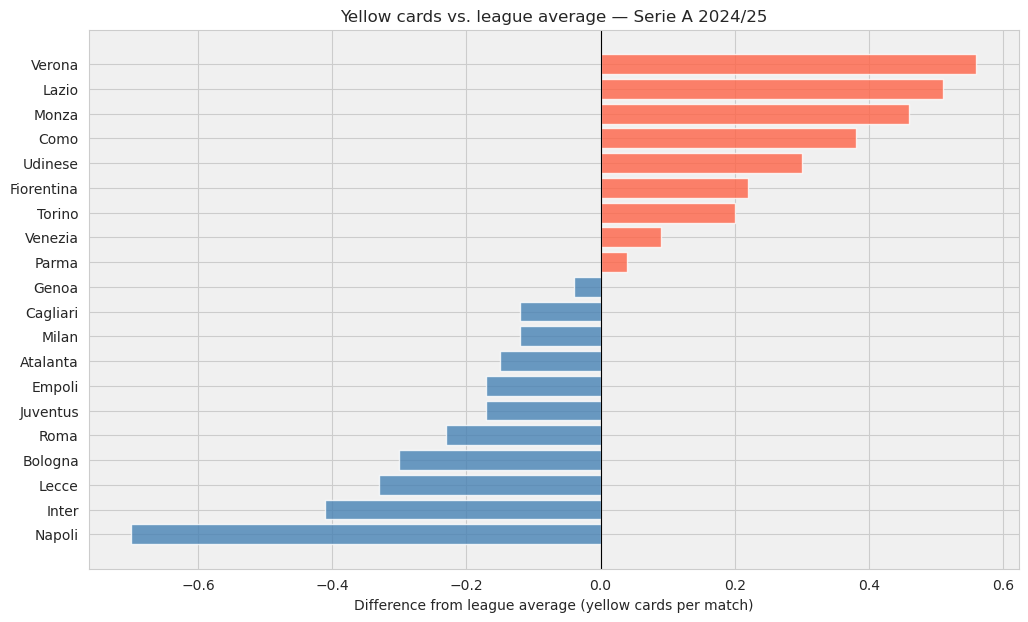

In [11]:
from discipline_stats import team_summary, plot_league_bar

summary_yc = team_summary(serie_a_2425, 'yellow_cards')
fig, ax = plot_league_bar(
    summary_yc.sort_values('diff_from_league', ascending=False),
    title='Yellow cards vs. league average — Serie A 2024/25',
    xlabel='Difference from league average (yellow cards per match)'
)
ax.invert_yaxis()
plt.show()

plt.show()

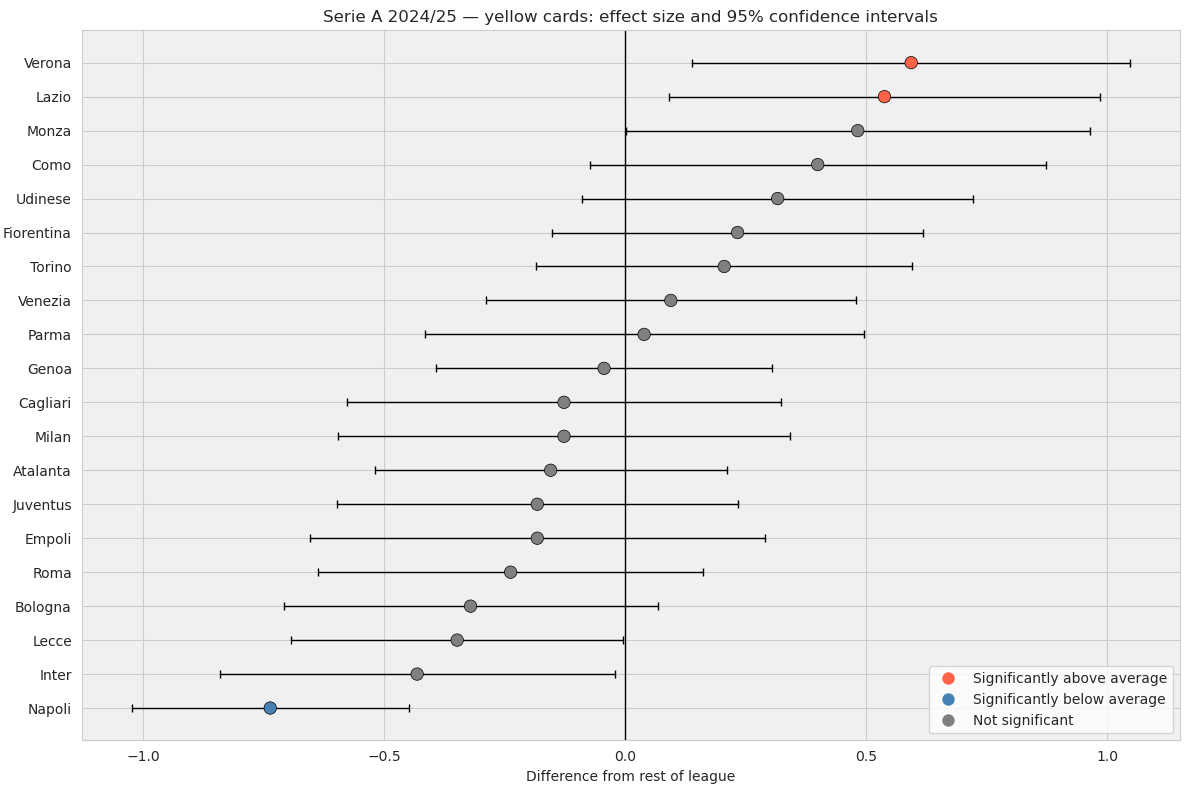

In [12]:
forest_df = results_yc.rename(columns={
    'difference (team-rest)': 'diff',
    'welch_t_p': 'welch_p'
})

fig, ax = plot_forest(
    forest_df, serie_a_2425, 'yellow_cards',
    title='Serie A 2024/25 — yellow cards: effect size and 95% confidence intervals'
)
plt.show()

The picture is sparser than the fouls analysis. With fouls, ten teams crossed the significance threshold. Here, only three do so convincingly.

**Significantly above average:**
Verona (d=0.43) and Lazio (d=0.39) stand out at the top. Both reach significance across all four tests. Verona was also the most fouling team in the league, so the pattern is consistent. Lazio, however, was one of the least fouling teams for fouls — yet here they sit near the top for yellow cards. A team that fouls relatively little but collects cards at an above-average rate. That discrepancy will matter in the next notebook.

**Significantly below average:**
Napoli is the clearest signal in the entire table. A mean of 1.2 cards per match against a league average of 1.9, Cohen's d of -0.65, and p-values near zero across all four tests. This is not a borderline result. Napoli received significantly fewer yellow cards than any other team in the league by a considerable margin.

**The grey zone:**
Monza and Inter sit in interesting territory. For Monza, Welch returns p=0.061 — just above the threshold — while the permutation test returns p=0.030. For Inter, the situation is nearly identical: Welch p=0.051, permutation p=0.047. Both teams hover at the boundary, and the parametric and non-parametric tests disagree slightly. With non-normal discrete data, this is exactly the kind of divergence we warned about. The permutation test is the more trustworthy reading here, but neither result is emphatic enough to treat as a strong finding.

**Everyone else** is indistinguishable from the league average. The forest plot makes this visible: most confidence intervals comfortably straddle zero.

The sparsity of significant results is not a failure of the analysis. It is a property of the data. Yellow cards are noisy, rare events. Detecting a genuine signal above that noise requires either a large effect or a lot of data. Napoli clears that bar easily. Most teams do not.

One final note on the forest plot. The error bars shown are symmetric 95% confidence intervals based on the standard error of the mean — a parametric construction that assumes the sampling distribution is approximately normal. This is a visualisation convenience, not a test result. The actual significance flags come from Mann-Whitney and the permutation test, which make no such assumption. A team whose error bar barely crosses zero might still be flagged as significant by the non-parametric tests, and vice versa. Read the plot as a guide to effect size and direction, not as a substitute for the p-values in the table.

### Where the new tests make a difference

For most teams the four tests agree, which is reassuring. But three cases are worth examining closely:

**Monza**: Student's t returns p=0.029 — significant. Welch returns p=0.061 — not significant. Mann-Whitney p=0.055, permutation p=0.030. The parametric tests disagree with each other, and the non-parametric tests split as well. This is a team sitting right on the boundary, and the answer you get depends on which tool you pick. With non-normal data, Welch and Mann-Whitney are the more trustworthy pair. Neither clears 0.05 convincingly. Treat Monza as inconclusive.

**Inter**: Welch p=0.051, Mann-Whitney p=0.059, permutation p=0.047. The permutation test alone crosses the threshold. A single test crossing 0.05 on the wrong side of the boundary is not a finding. It is a flag that says: more data needed.

**Napoli**: all four tests agree emphatically, but notice something specific. Welch returns p=0.0000 while Student's t returns p=0.0008. The difference arises because Napoli's standard deviation (0.91) is dramatically lower than the rest of the league (1.34). Unequal variance, exactly the condition where Welch and Student diverge. Had we used Student's t uncritically, we would have underestimated the significance. This is a small but concrete example of why checking assumptions before choosing a test is not a formality.


## Fouls and yellow cards: a comparison

We have now run the same analysis twice on the same league and season. Before we close, it is worth putting the two sets of results side by side. Not to rank the metrics, but to see what they agree on, where they diverge, and what those divergences might mean.

| Team | Fouls rank | Fouls d | Yellow cards rank | YC d | Pattern |
|------|:--:|:--:|:--:|:--:|---------|
| Verona | 1st | +0.62 | 1st | +0.43 | Consistently aggressive |
| Empoli | 2nd | +0.58 | 12th | -0.13 | Many fouls, average cards |
| Udinese | 3rd | +0.45 | 5th | +0.24 | Consistently physical |
| Bologna | 4th | +0.44 | 17th | -0.25 | Many fouls, few cards |
| Lazio | 19th | -0.39 | 2nd | +0.39 | Few fouls, many cards |
| Roma | 18th | -0.50 | 15th | -0.18 | Few fouls, average cards |
| Napoli | 17th | -0.43 | 20th | -0.65 | Consistently clean |
| Inter | 16th | -0.41 | 19th | -0.33 | Consistently clean |

The teams at the extremes tell three different stories.

**Consistent teams**: Verona is aggressive by both measures. Napoli and Inter are clean by both measures. The two metrics point in the same direction.

**High fouls, average or low cards**: Empoli and Bologna commit significantly more fouls than the league average but do not receive significantly more yellow cards. Either their fouls are less card-worthy in nature, or referees apply a different threshold to them.

**Low fouls, high cards**: Lazio is the most striking case. One of the least fouling teams in the league, yet one of the most booked. This is the anomaly that the rate analysis in the next notebook is built to investigate.

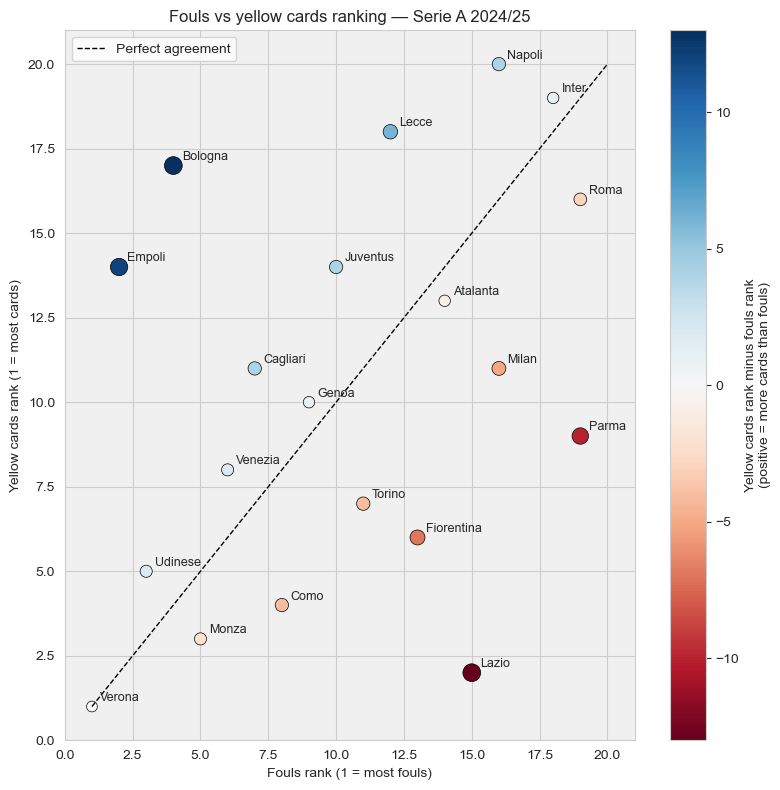

In [13]:
fouls_results = test_all_teams(serie_a_2425, 'fouls_committed')
yc_results = results_yc.copy()

fouls_results['fouls_rank'] = fouls_results['team_mean'].rank(ascending=False).astype(int)
yc_results['yc_rank'] = yc_results['team_mean'].rank(ascending=False).astype(int)

merged = fouls_results[['team', 'fouls_rank']].merge(
    yc_results[['team', 'yc_rank']], on='team'
)

merged['distance'] = merged['yc_rank'] - merged['fouls_rank']
max_dist = merged['distance'].abs().max()

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_facecolor('#f0f0f0')

    scatter = ax.scatter(
        merged['fouls_rank'], merged['yc_rank'],
        c=merged['distance'], cmap='RdBu', vmin=-max_dist, vmax=max_dist,
        s=merged['distance'].abs() * 8 + 60,
        zorder=2, edgecolors='black', linewidth=0.5
    )

    for _, row in merged.iterrows():
        ax.annotate(row['team'], (row['fouls_rank'], row['yc_rank']),
                    textcoords='offset points', xytext=(6, 4), fontsize=9)

    ax.plot([1, 20], [1, 20], color='black', linestyle='--',
            linewidth=1, label='Perfect agreement')

    plt.colorbar(scatter, ax=ax, label='Yellow cards rank minus fouls rank\n(positive = more cards than fouls)')
    ax.set_xlabel('Fouls rank (1 = most fouls)')
    ax.set_ylabel('Yellow cards rank (1 = most cards)')
    ax.set_title('Fouls vs yellow cards ranking — Serie A 2024/25')
    ax.set_xlim(0, 21)
    ax.set_ylim(0, 21)
    ax.legend()
    plt.tight_layout()
    plt.show()

The scatter plot makes the story visible in a way the table cannot.

Teams close to the diagonal are consistent: their fouling rank and yellow cards rank tell the same story. Verona sits almost exactly on the line — the most fouling team and one of the most booked. Napoli sits near the diagonal too, at the opposite extreme: few fouls, few cards.

The interesting teams are the ones far from the line.

**Blue (more fouls than cards):** Bologna and Empoli stand out. Both commit significantly more fouls than average, yet their yellow card rates are unremarkable. They foul, but they do not get booked for it at the same rate. Whether this reflects the nature of their fouls, their style of play, or a degree of referee leniency is a question the data alone cannot answer.

**Red (more cards than fouls):** Lazio is the most striking point on the entire plot. One of the least fouling teams in the league, yet the second most booked. The gap between their fouls rank (15th) and their yellow cards rank (2nd) is the largest in the dataset. Roma and Parma show a similar but milder pattern: fewer fouls than you would expect given their card count.

This is the question the next notebook is built to answer. The conversion rate from foul to yellow card is not constant. It varies by team, and the variation is large enough to be visible. Whether that variation reflects tactical style, referee perception, or something else entirely is where the investigation goes next.


## What we found, and what we didn't

We started with the same questions as the fouls notebook and the same league and season. The answers came out differently, and understanding why is the point.

Away teams receive significantly more yellow cards than home teams, with a stronger and cleaner signal than we found for fouls. The effect is small in absolute terms — 0.4 cards per match — but consistent across all four tests. The most plausible explanation is referee judgement influenced by crowd pressure, but that is a hypothesis the data is consistent with, not one it proves.

The cross-league comparison surprised us. Italian referees call nearly three more fouls per match than English ones, yet the two leagues are statistically indistinguishable in yellow cards per match. The extra fouls in Serie A do not become extra bookings. The conversion rate from foul to card is not the same everywhere.

At the team level, only three teams stand out convincingly: Verona and Lazio above average, Napoli below. Far fewer than the ten significant teams we found for fouls. This is not a failure of the analysis. Yellow cards are rarer and noisier than fouls, and rarer events require larger effects or more data to produce a clear signal.

The new tools earned their place. Mann-Whitney and the permutation test agreed with the t-tests in most cases, which is reassuring. Where they disagreed — Monza, Inter — the disagreement was itself informative: those teams sit at a boundary where no single test should be trusted alone.

The scatter plot at the end is the most important result in the notebook. Fouls and yellow cards do not tell the same story for every team. Bologna fouls a lot and gets average cards. Lazio fouls little and gets many cards. The gap between the two metrics is the question we have been building towards since the first notebook.

That is where we are going next.


### Appendix - the data

The data used in this notebook comes from [football-data.co.uk](https://www.football-data.co.uk/). A sample-based validation was performed across all datasets, with manual lookup against [fbref.com](https://fbref.com/) and [ESPN](https://www.espn.co.uk/football/) for flagged outliers. 